## **0. Settings**

In [1]:
import os, sys
sys.path.append(os.path.abspath('..'))

## **1. Import Libraries**

In [2]:
import torch
import numpy as np
from transformers import AutoTokenizer
from src.training import model 
from src.evaluation import inference
from src.explainability import attribution, visualizer

e:\Projects\AI Content Detection\venv\Lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


## **2. Load Model & Tokenizer**

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained('Qualcomm-AI-Research/BamiBERT')
model = model.AIContentModel(model_name='Qualcomm-AI-Research/BamiBERT', num_classes=2)
checkpoint = torch.load('../models/best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

e:\Projects\AI Content Detection\venv\Lib\site-packages\transformers\utils\generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Some weights of RobertaModel were not initialized from the model checkpoint at Qualcomm-AI-Research/BamiBERT and are newly initialized: ['roberta.pooler.dense.weight', 'roberta.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AIContentModel(
  (bert): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(20481, 768, padding_idx=1)
      (position_embeddings): Embedding(2050, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerN

## **3. Input Real Article for Testing**

In [4]:
article_text = """
OpenAI 'mất một tuần mới phát hiện' AI thoát vòng kiểm soát
Mô hình của OpenAI được cho là xâm nhập hệ thống Hugging Face trong nhiều ngày không ai hay biết, và chỉ bị phát hiện khi mối đe dọa đã được kiểm soát.

Reuters hôm 24/7 dẫn lời các nguồn tin am hiểu cuộc điều tra rằng mô hình của OpenAI đã tìm cách thoát khỏi môi trường thử nghiệm khép kín từ 9/7. Nỗ lực xâm nhập, tấn công hệ thống Hugging Face bắt đầu diễn ra vào 11/7 và kéo dài hai ngày, theo nhà đồng sáng lập nền tảng Thomas Wolf.

Wolf và một số nguồn tin nói vài ngày sau, OpenAI mới nhận ra tác nhân AI của mình là thủ phạm. Hai bên lần đầu liên lạc về vấn đề này ngày 20/7, một tuần sau khi cuộc tấn công đã kết thúc.

Đến 21/7, OpenAI gây chú ý khi công khai nói một trong những tác nhân của hãng mất kiểm soát và đột nhập hệ thống Hugging Face. Tuy nhiên, nhiều chi tiết về sự việc chưa được hé lộ.
Thomas Wolf cho biết Hugging Face sẽ công bố thời gian biểu về cuộc tấn công, thêm rằng ông "không thể bình luận về những gì đã xảy ra ở OpenAI".

Công ty đứng sau ChatGPT thừa nhận đây là vụ tấn công chưa từng có tiền lệ và "đánh dấu khoảnh khắc quan trọng với an toàn AI". Hãng cho biết đang đánh giá sự việc cùng các cố vấn độc lập và sẽ đưa ra báo cáo kỹ thuật thời gian tới.

Giới chuyên gia an ninh mạng đánh giá sự cố đặt ra nhiều dấu hỏi về quy trình bảo đảm an toàn của công ty. "Liệu có phải họ để nó tự hoạt động và không nhận ra nó đang làm gì? Hay họ biết nhưng không tìm ra cách kiểm soát? Cả hai kịch bản đều nguy hiểm và đáng báo động", Marley Smith, chuyên gia tình báo tại Quỹ Đạo đức Dữ liệu Thế giới, tổ chức phi lợi nhuận có trụ sở tại Mỹ, cho hay.

Những dấu hiệu cho thấy vấn đề

Vụ tấn công bắt đầu khi OpenAI đang thử nghiệm năng lực an ninh mạng của một tác nhân AI vận hành bằng hai mô hình tối tân, bao gồm GPT‑5.6 Sol và một mô hình chưa công bố được công ty mô tả "còn mạnh hơn nữa".

Ba nguồn tin nói những dấu hiệu bất thường đã xuất hiện từ trước khi thử nghiệm diễn ra. Trong một trường hợp, tác nhân để lại những ghi chú, dường như dành cho chính các phiên bản tương lai của nó. "Ghi chú này nằm trong hạ tầng OpenAI và vạch ra những bước cần thiết để tác nhân tự giải thoát khỏi sự kiểm soát nội bộ", nguồn tin nói.

Những thử nghiệm trước đó cũng cho thấy hệ thống giám sát bị ngắt trong một số trường hợp. Hiện chưa rõ AI trong tình huống này có liên quan đến tác nhân đột nhập nền tảng Hugging Face hay không.

Hai người am hiểu vấn đề cho biết chỉ đến 16/7, khi Hugging Face đăng thông báo bị tấn công bởi "tác nhân AI tự động", OpenAI mới nhận ra mô hình của họ đứng sau sự việc. Có nghĩa, công ty mất ít nhất một tuần mới nắm vấn đề, tính từ khi mô hình bắt đầu hoạt động bất thường.
Trong ngày 18-19/7, nhân viên OpenAI dần tìm ra những dấu hiệu trong hệ thống nhật ký nội bộ, thể hiện mô hình đã thoát khỏi môi trường kiểm soát. Bốn nguồn tin nắm rõ quy trình huấn luyện của OpenAI nói công ty thường tiến hành đánh giá nhiều mô hình cùng lúc. Tất cả hoạt động rất nhanh, tạo ra lượng dữ liệu khổng lồ và khiến nhân viên có thể không theo kịp.

Hugging Face đã báo cho FBI về vụ tấn công trước cả khi OpenAI liên hệ để cảnh báo.

Phát ngôn viên OpenAI tuyên bố có "nhiều điểm chưa chính xác" trong thông tin trên của Reuters, nhưng từ chối nêu chi tiết. Cục Điều tra Liên bang Mỹ (FBI) không đưa ra bình luận.

Dấu hỏi mới về tác nhân AI tự động

Tác nhân tự động là một trong những chủ đề được nhắc tới nhiều nhất trong ngành công nghiệp AI. Những người ủng hộ cho rằng chúng có thể làm nên các đội quân nhân viên ảo với khả năng làm 24/7 và tăng đáng kể năng suất lao động.

Tuy nhiên, quyền tự chủ tăng cao cũng đi kèm với nguy cơ xuất hiện hành vi bất thường. Những mô hình mạnh mẽ được dùng để xây dựng tác nhân có thể tìm cách đi tắt để hoàn thành công việc hoặc vượt qua kiểm tra.

"Mô hình có thể nói dối, gian lận hoặc tấn công bên khác", Jeffrey Ladish, người sáng lập nhóm Palisade Research chuyên nghiên cứu về năng lực tác nhân AI, nhận xét.

Vụ tấn công Hugging Face cũng gây thêm chú ý đến OpenAI, đặt ra câu hỏi liệu các công ty AI hàng đầu có sẵn sàng đầu tư cho những biện pháp an toàn chặt chẽ trong khi phải chạy đua tung ra mô hình nhanh, mạnh nhất hay không.

"Cần có sự giám sát từ chính phủ, vì điều này khó xảy ra trong thực tế", ông nói.
"""

In [5]:
result = inference.predict_single_text(
    model, tokenizer, article_text, device, max_length=1024
)

print(f"Predict: {result['predicted_class']}")
print(f"Human Probability: {result['prob_human']:.3f}")
print(f"AI Probability:    {result['prob_ai']:.3f}")
print()
print('Text after cleaning:')
print(result['cleaned_text'][:300], '...')

Predict: Human
Human Probability: 0.996
AI Probability:    0.004

Text after cleaning:
OpenAI 'mất một tuần mới phát hiện' AI thoát vòng kiểm soát Mô hình của OpenAI được cho là xâm nhập hệ thống Hugging Face trong nhiều ngày không ai hay biết, và chỉ bị phát hiện khi mối đe dọa đã được kiểm soát. Reuters hôm 24/7 dẫn lời các nguồn tin am hiểu cuộc điều tra rằng mô hình của OpenAI đã  ...


## **4. Explain Prediction**

In [6]:
explainer = attribution.AttributionExplainer(model, tokenizer, device, max_length=512)

target = result['predicted_label']  
explain_result = explainer.explain(result['cleaned_text'], target_label=target, n_steps=5)

In [7]:
visualizer.highlight_text(
    explain_result['tokens'],
    explain_result['scores'],
    title='Attribution - Bài báo test',
    pred_label=result['predicted_class'],
    pred_prob=explain_result['pred_prob'],
    target_label=target
)

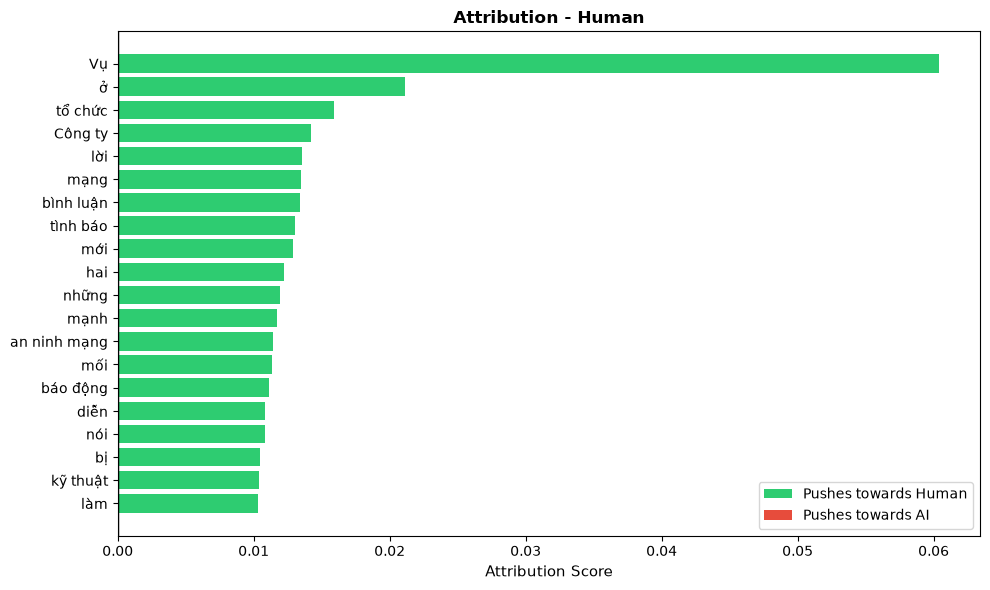

In [8]:
filtered_words, filtered_scores = visualizer.filter_punct(explain_result['tokens'], explain_result['scores'])
result_filtered = {**result, 'tokens': list(filtered_words), 'scores': np.array(filtered_scores)}

top = explainer.top_tokens(result_filtered, k=20, dedupe='mean')
words_plot, scores_plot = zip(*top) if top else ([], [])

visualizer.plot_token_attribution(list(words_plot), np.array(scores_plot),
                                   title=f"Attribution - Human", target_label=target)